In [1]:
# LIBRERIE DI BASE E VISUALIZZAZIONE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# SCIKIT-LEARN: PRE-PROCESSING, MODELLI TRADIZIONALI E METRICHE
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, precision_recall_curve, auc

# PYTORCH: RETE NEURALE
import torch
import torch.nn as nn
import torch.optim as optim

#### Carico i dati ed effettuo le stesso operazioni dell'altro notebook

In [2]:
data = pd.read_csv("./dataset/loan_data.csv")

In [3]:
print(len(data))
data = data[(data['person_age'] <= 80) & (data['person_emp_exp'] <= 60)] #OCCUPIAMOCI DEI DATI "STRANI" COME ETA' DI 144 ANNI
print(len(data))

45000
44990


In [4]:
data['employment_ratio'] = data['person_emp_exp'] / data['person_age']

data = data.drop(['person_emp_exp'], axis=1)

In [5]:
X = data.drop('loan_status', axis=1)
y = data['loan_status'].values.reshape(-1, 1)

In [6]:

num_features = ['person_age', 'person_income', 'employment_ratio', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score'] # Solo quelle continue/discrete vere
cat_features = ['person_gender', 'person_education','person_home_ownership','loan_intent','previous_loan_defaults_on_file'] # Quelle categoriche da codificare


# 2. Creiamo il ColumnTransformer 
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first'), cat_features),
        ])

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [8]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [9]:
# CONVERSIONE IN TENSORI PYTORCH

X_train_tensor = torch.FloatTensor(X_train)
X_test_tensor = torch.FloatTensor(X_test)

y_train_tensor = torch.FloatTensor(y_train)
y_test_tensor = torch.FloatTensor(y_test)

In [10]:
class LoanPredictor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        # self.network = nn.Sequential( 
        #    nn.Linear(input_dim, 36),
        #    nn.ReLU(),
        #    nn.Linear(36, 18),
        #    nn.ReLU(),
        #    nn.Linear(18, 1),
        #    nn.Sigmoid()
        # )


        # self.network = nn.Sequential(
        #    nn.Linear(input_dim, 8),
        #    nn.ReLU(),
        #    nn.Linear(8, 4),
        #    nn.ReLU(),
        #    nn.Linear(4, 1),
        #    nn.Sigmoid()
        #  )

        self.network = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
            )
        
    
        # self.network = nn.Sequential(
        #    nn.Linear(input_dim, 18),
        #    nn.ReLU(),
        #    nn.Linear(18, 9),
        #    nn.ReLU(),
        #    nn.Linear(9, 1),
        #    nn.Sigmoid()
        # )

       
    def forward(self, x):  #forward pass della rete neurale -> prende l'input x e lo fa passare attraverso tutti gli strati della rete nell'ordine definito
        return self.network(x)

In [25]:
torch.manual_seed(42) #rende i calcoli casuali perfettamente riproducibili.
input_dim = X_train_tensor.shape[1]
model = LoanPredictor(input_dim)

In [12]:
#  LOSS E OTTIMIZZATORE
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [13]:
# 8. CICLO DI ADDESTRAMENTO


def train_model(model, epochs=500):

        #Imposto il modello in modalità addestramento (fuori dal ciclo)
    model.train()
    
    for epoch in range(epochs):
        # Forward pass: calcolo delle predizioni
        predictions = model(X_train_tensor)
        
        # Calcolo dell'errore
        loss = criterion(predictions, y_train_tensor)

        # Backward pass e ottimizzazione
        optimizer.zero_grad() # reset dei gradienti
        loss.backward()       # Calcolo dei nuovi gradienti
        optimizer.step()      # Aggiornamento dei pesi

        # Stampa a schermo ogni 15 epochs
        if epoch % 15 == 0:
            print(f"Epoch {epoch} | Loss: {loss.item():.4f}")
            
    #Imposto il modello in modalità valutazione a fine addestramento
    model.eval()

In [14]:
train_model(model, 200)

Epoch 0 | Loss: 0.6520
Epoch 15 | Loss: 0.3693
Epoch 30 | Loss: 0.2678
Epoch 45 | Loss: 0.2202
Epoch 60 | Loss: 0.2049
Epoch 75 | Loss: 0.1950
Epoch 90 | Loss: 0.1885
Epoch 105 | Loss: 0.1841
Epoch 120 | Loss: 0.1810
Epoch 135 | Loss: 0.1782
Epoch 150 | Loss: 0.1759
Epoch 165 | Loss: 0.1739
Epoch 180 | Loss: 0.1723
Epoch 195 | Loss: 0.1708


In [15]:
# Spegniamo il motore dei gradienti per risparmiare memoria e potenza di calcolo
with torch.no_grad(): 
    # Passiamo il test set alla rete per ottenere le predizioni
    probas = model(X_test_tensor)
    predicted = (probas > 0.5).float() 

In [16]:
y_test_np = y_test_tensor.numpy()
y_pred_np = predicted.numpy()


In [17]:
print(classification_report(y_test_np, y_pred_np, target_names=['Respinto','Accettato']))

              precision    recall  f1-score   support

    Respinto       0.94      0.96      0.95      6998
   Accettato       0.85      0.77      0.81      2000

    accuracy                           0.92      8998
   macro avg       0.90      0.87      0.88      8998
weighted avg       0.92      0.92      0.92      8998



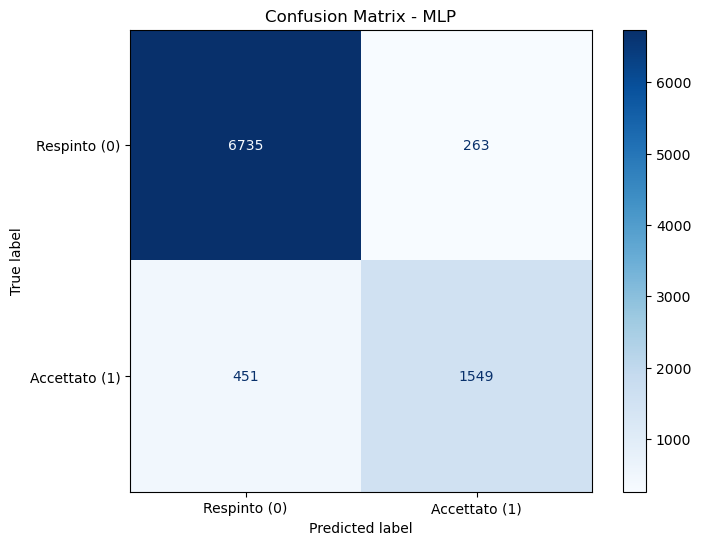

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Assumendo che tu abbia già y_true e y_pred come nel passaggio precedente
# Calcola la matrice
cm = confusion_matrix(y_test_np, y_pred_np)

# Visualizza la matrice
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Respinto (0)', 'Accettato (1)'])

# Crea il grafico
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax)

plt.title('Confusion Matrix - MLP')
plt.show()

In [19]:
precision, recall, thresholds = precision_recall_curve(y_test_np, probas)
auc = auc(recall, precision)

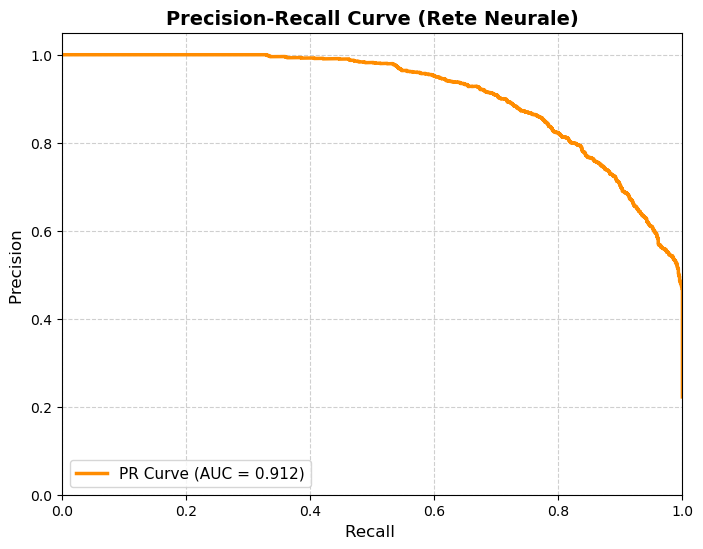

In [20]:
# 2. Creazione del grafico (Stile Professionale)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='darkorange', lw=2.5, label=f'PR Curve (AUC = {auc:.3f})')

# 3. Formattazione
plt.title('Precision-Recall Curve (Rete Neurale)', fontsize=14, fontweight='bold')
plt.xlabel('Recall ', fontsize=12)
plt.ylabel('Precision ', fontsize=12)
plt.legend(loc='lower left', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

# Imposta i limiti degli assi rigorosamente tra 0 e 1
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

# 4. Mostra il grafico
plt.show()

In [21]:
for s in [0.4, 0.5, 0.7]:
    preds = (probas > s).float().numpy()
    p = precision_score(y_test_np, preds, pos_label=1)
    r = recall_score(y_test_np, preds, pos_label=1)
    print(f"Soglia {s} -> Precision (Classe 1): {p:.2f} | Recall (Classe 1): {r:.2f}")

Soglia 0.4 -> Precision (Classe 1): 0.80 | Recall (Classe 1): 0.82
Soglia 0.5 -> Precision (Classe 1): 0.85 | Recall (Classe 1): 0.77
Soglia 0.7 -> Precision (Classe 1): 0.92 | Recall (Classe 1): 0.67
